# L=32 raw-spin PCA analysis

This repeats the ResNet analysis on the same 410,000 seed-temperature observations using only the flattened 32x32 mean spin fields.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

L = 32
N_RUNS = 10_000
N_TEMPERATURES = 41
BINS_PER_TEMPERATURE = 10
TEMPERATURES = np.round(np.arange(2.2, 2.4001, 0.005), 3)
TC = 2.0 / np.log(1.0 + np.sqrt(2.0))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REPO_ROOT = Path.home() / "senior-thesis"
RAW_ROOT = REPO_ROOT / "data/raw/ising32_tc_zoom"
OUTPUT_ROOT = REPO_ROOT / "data/processed/ising32_tc_zoom"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

runs = sorted(RAW_ROOT.glob("ising32_tc_zoom_[0-9]*"), key=lambda p: int(p.name.rsplit("_", 1)[1]))
assert len(runs) == N_RUNS, len(runs)
print(f"{len(runs):,} runs; {len(TEMPERATURES)} temperatures; device={DEVICE}")

10,000 runs; 41 temperatures; device=cuda


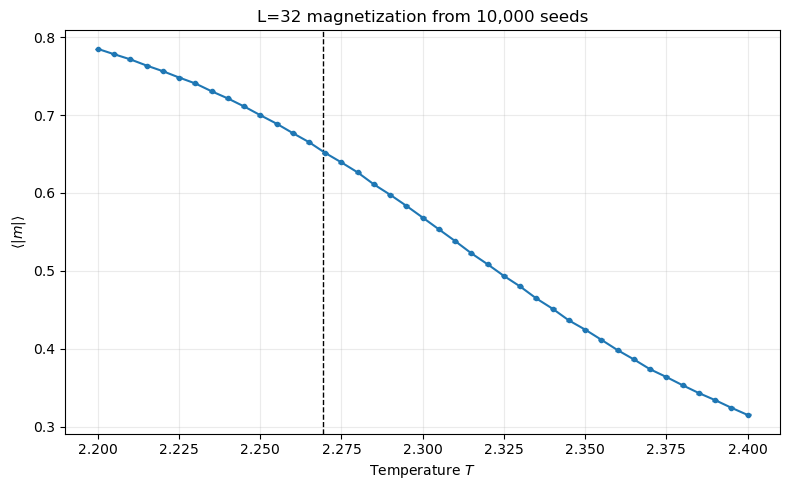

In [2]:
MEAN_SPINS_PATH = OUTPUT_ROOT / "seed_temperature_mean_spins.npy"
MAG_PATH = OUTPUT_ROOT / "seed_temperature_signed_magnetization.npy"

if not MEAN_SPINS_PATH.exists():
    mean_spins = np.lib.format.open_memmap(
        MEAN_SPINS_PATH, mode="w+", dtype=np.float16,
        shape=(N_RUNS, N_TEMPERATURES, L, L),
    )
    magnetization = np.lib.format.open_memmap(
        MAG_PATH, mode="w+", dtype=np.float32,
        shape=(N_RUNS, N_TEMPERATURES),
    )
    for run_index, run_dir in enumerate(runs):
        name = run_dir.name
        spins = np.loadtxt(run_dir / f"spinConfigs_{name}.txt", dtype=np.int8)
        spins = spins.reshape(N_TEMPERATURES, BINS_PER_TEMPERATURE, L, L)
        mean_spins[run_index] = spins.mean(axis=1)
        magnetization[run_index] = spins.mean(axis=(1, 2, 3), dtype=np.float64)
        if (run_index + 1) % 500 == 0:
            print(f"Reduced {run_index + 1:,}/{N_RUNS:,} runs")
    mean_spins.flush(); magnetization.flush()

mean_spins = np.load(MEAN_SPINS_PATH, mmap_mode="r")
magnetization = np.load(MAG_PATH, mmap_mode="r")
assert mean_spins.shape == (N_RUNS, N_TEMPERATURES, L, L)

ABS_MAG_PATH = OUTPUT_ROOT / "seed_temperature_absolute_magnetization.npy"
if not ABS_MAG_PATH.exists():
    absolute_magnetization = np.lib.format.open_memmap(
        ABS_MAG_PATH, mode="w+", dtype=np.float32,
        shape=(N_RUNS, N_TEMPERATURES),
    )
    for run_index, run_dir in enumerate(runs):
        name = run_dir.name
        spins = np.loadtxt(run_dir / f"spinConfigs_{name}.txt", dtype=np.int8)
        spins = spins.reshape(N_TEMPERATURES, BINS_PER_TEMPERATURE, L, L)
        configuration_m = spins.sum(axis=(2, 3), dtype=np.int32) / (L * L)
        absolute_magnetization[run_index] = np.abs(configuration_m).mean(axis=1)
        if (run_index + 1) % 500 == 0:
            print(f"Recomputed |m| for {run_index + 1:,}/{N_RUNS:,} runs")
    absolute_magnetization.flush()

absolute_magnetization = np.load(ABS_MAG_PATH, mmap_mode="r")
mean_abs_m = absolute_magnetization.mean(axis=0)
sem_abs_m = absolute_magnetization.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
assert np.all((mean_abs_m >= 0) & (mean_abs_m <= 1))
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(TEMPERATURES, mean_abs_m, yerr=sem_abs_m, marker="o", ms=3, capsize=2)
ax.axvline(TC, color="black", ls="--", lw=1)
ax.set(xlabel="Temperature $T$", ylabel=r"$\langle |m|\rangle$", title="L=32 magnetization from 10,000 seeds")
ax.grid(alpha=.25); fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ising32_magnetization_zoom.png", dpi=250)
plt.show()

In [3]:
def exact_pca(features, cache_name, batch_size=4096):
    cache = OUTPUT_ROOT / cache_name
    if cache.exists():
        data = np.load(cache)
        return data["mean"], data["eigenvalues"], data["components"]
    dimension = features.shape[1]
    total = torch.zeros(dimension, dtype=torch.float64, device=DEVICE)
    second = torch.zeros((dimension, dimension), dtype=torch.float64, device=DEVICE)
    for start in range(0, len(features), batch_size):
        batch = torch.from_numpy(np.asarray(features[start:start + batch_size], dtype=np.float32)).to(DEVICE, dtype=torch.float64)
        total += batch.sum(0); second += batch.T @ batch
    mean_t = total / len(features)
    covariance = (second - len(features) * torch.outer(mean_t, mean_t)) / (len(features) - 1)
    values, vectors = torch.linalg.eigh(covariance)
    order = torch.argsort(values, descending=True)
    mean = mean_t.cpu().numpy(); eigenvalues = values[order].cpu().numpy(); components = vectors[:, order].T.cpu().numpy()
    np.savez(cache, mean=mean, eigenvalues=eigenvalues, components=components)
    return mean, eigenvalues, components

def score_memmap(features, mean, components, path, batch_size=8192):
    if path.exists(): return np.load(path, mmap_mode="r")
    scores = np.lib.format.open_memmap(path, mode="w+", dtype=np.float32, shape=(len(features), len(components)))
    for start in range(0, len(features), batch_size):
        stop = min(start + batch_size, len(features))
        scores[start:stop] = (np.asarray(features[start:stop], np.float32) - mean) @ components.T
    scores.flush(); return np.load(path, mmap_mode="r")

def variance_plot(eigenvalues, prefix):
    evr = eigenvalues / eigenvalues.sum(); cumulative = np.cumsum(evr)
    n90 = int(np.searchsorted(cumulative, .90) + 1)
    x = np.arange(1, n90 + 1)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x, evr[:n90], alpha=.8); ax.set(xlabel="PC", ylabel="Explained variance ratio", title=f"{prefix}: {n90} PCs retain 90%")
    other = ax.twinx(); other.plot(x, cumulative[:n90], "o-", color="tab:red", ms=3); other.axhline(.9, color="black", ls="--"); other.set_ylabel("Cumulative variance")
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / f"{prefix}_variance.png", dpi=250); plt.show()
    return evr, cumulative, n90

def pc_visuals(scores, prefix):
    grids = mean_spins.reshape(-1, L, L)
    tail = max(1, int(.02 * len(scores)))
    rows = []

    fig, axes = plt.subplots(5, 3, figsize=(10, 16), constrained_layout=True)
    residual_fig, residual_axes = plt.subplots(5, 3, figsize=(10, 16), constrained_layout=True)

    for pc in range(5):
        values = np.asarray(scores[:, pc])
        order = np.argsort(values)
        low, high = order[:tail], order[-tail:]

        low_grids = np.asarray(grids[low], np.float32)
        high_grids = np.asarray(grids[high], np.float32)
        low_map = low_grids.mean(axis=0)
        high_map = high_grids.mean(axis=0)
        contrast = high_map - low_map

        raw_limit = max(float(np.max(np.abs(low_map))), float(np.max(np.abs(high_map))), 1e-3)
        contrast_limit = max(float(np.max(np.abs(contrast))), 1e-3)
        raw_panels = (
            (low_map, "lowest 2%", raw_limit),
            (high_map, "highest 2%", raw_limit),
            (contrast, "high-low", contrast_limit),
        )
        for col, (data, title, limit) in enumerate(raw_panels):
            im = axes[pc, col].imshow(data, cmap="RdBu_r", vmin=-limit, vmax=limit)
            axes[pc, col].set_title(f"PC{pc + 1} {title}")
            axes[pc, col].set_xticks([]); axes[pc, col].set_yticks([])
            fig.colorbar(im, ax=axes[pc, col], fraction=.046)

        low_residual = (low_grids - low_grids.mean(axis=(1, 2), keepdims=True)).mean(axis=0)
        high_residual = (high_grids - high_grids.mean(axis=(1, 2), keepdims=True)).mean(axis=0)
        residual_contrast = high_residual - low_residual
        residual_limit = max(
            float(np.max(np.abs(low_residual))),
            float(np.max(np.abs(high_residual))),
            float(np.max(np.abs(residual_contrast))),
            1e-4,
        )
        residual_panels = (
            (low_residual, "lowest 2%"),
            (high_residual, "highest 2%"),
            (residual_contrast, "high-low"),
        )
        for col, (data, title) in enumerate(residual_panels):
            im = residual_axes[pc, col].imshow(
                data, cmap="RdBu_r", vmin=-residual_limit, vmax=residual_limit
            )
            residual_axes[pc, col].set_title(f"PC{pc + 1} {title}")
            residual_axes[pc, col].set_xticks([]); residual_axes[pc, col].set_yticks([])
            residual_fig.colorbar(im, ax=residual_axes[pc, col], fraction=.046)

        rows.append({
            "pc": pc + 1,
            "min_index": int(np.argmin(values)),
            "max_index": int(np.argmax(values)),
            "low_m": float(low_map.mean()),
            "high_m": float(high_map.mean()),
            "mean_subtracted_rms": float(np.sqrt(np.mean(residual_contrast ** 2))),
            "mean_subtracted_range": float(np.ptp(residual_contrast)),
        })

    fig.suptitle(f"{prefix} PC-tail mean spin fields (adaptive scale)")
    fig.savefig(OUTPUT_ROOT / f"{prefix}_pc_tail_maps.png", dpi=250, bbox_inches="tight")
    plt.show(); plt.close(fig)

    residual_fig.suptitle(
        f"{prefix} PC-tail fields after subtracting each observation's spatial mean"
    )
    residual_fig.savefig(
        OUTPUT_ROOT / f"{prefix}_pc_tail_mean_subtracted.png",
        dpi=250, bbox_inches="tight",
    )
    plt.show(); plt.close(residual_fig)
    pd.DataFrame(rows).to_csv(OUTPUT_ROOT / f"{prefix}_pc_tail_summary.csv", index=False)

def cluster_analysis(features, scores90, prefix):
    models = {"PCA 90%": MiniBatchKMeans(3, random_state=42, batch_size=4096, n_init=20), "Full": MiniBatchKMeans(3, random_state=42, batch_size=4096, n_init=20)}
    labels = {"PCA 90%": models["PCA 90%"].fit_predict(scores90), "Full": models["Full"].fit_predict(features)}
    flat_m = np.asarray(magnetization).reshape(-1)
    flat_t = np.tile(TEMPERATURES, N_RUNS)
    rows=[]
    for method, lab in labels.items():
        order=np.argsort([flat_m[lab==c].mean() for c in range(3)]); remap=np.empty(3,int); remap[order]=np.arange(3); lab=remap[lab]; labels[method]=lab
        for ti,t in enumerate(TEMPERATURES):
            at=lab[flat_t==t]
            for c in range(3): rows.append({"method":method,"temperature":t,"cluster":c,"fraction":float(np.mean(at==c))})
    table=pd.DataFrame(rows); table.to_csv(OUTPUT_ROOT / f"{prefix}_cluster_populations.csv",index=False)
    fig,axes=plt.subplots(1,2,figsize=(14,5),sharex=True,sharey=True)
    for ax,method in zip(axes,labels):
        for c in range(3):
            d=table[(table.method==method)&(table.cluster==c)]; ax.plot(d.temperature,d.fraction,"o-",ms=3,label=f"Cluster {c}")
        ax.axvline(TC,color="black",ls="--"); ax.set(title=method,xlabel="T",ylim=(-.02,1.02)); ax.grid(alpha=.25); ax.legend()
    axes[0].set_ylabel("Cluster fraction"); fig.suptitle(f"{prefix} unsupervised clusters"); fig.tight_layout(); fig.savefig(OUTPUT_ROOT / f"{prefix}_cluster_populations.png",dpi=250); plt.show()
    np.savez(OUTPUT_ROOT / f"{prefix}_cluster_labels.npz",pca90=labels["PCA 90%"],full=labels["Full"])
    return labels

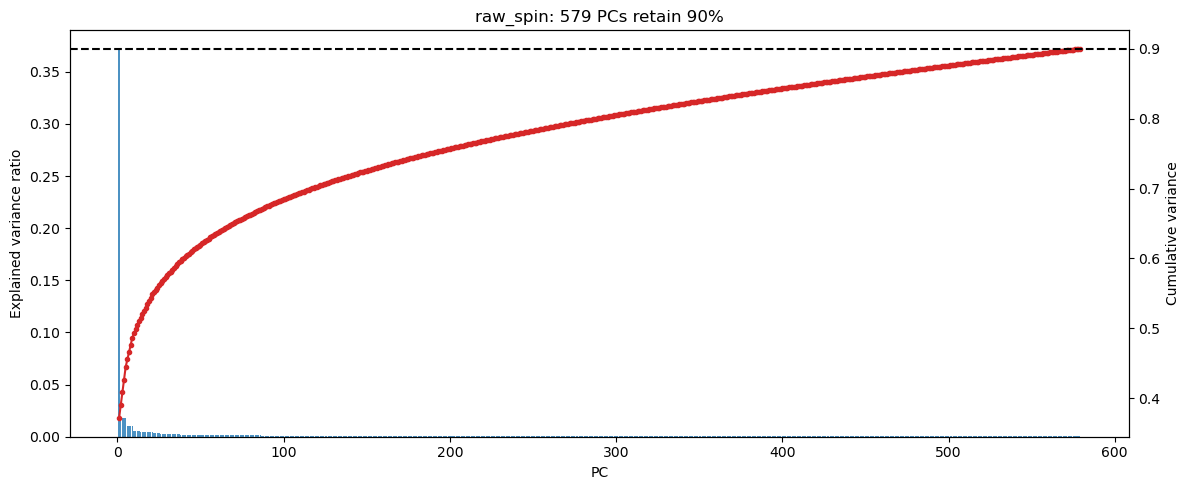

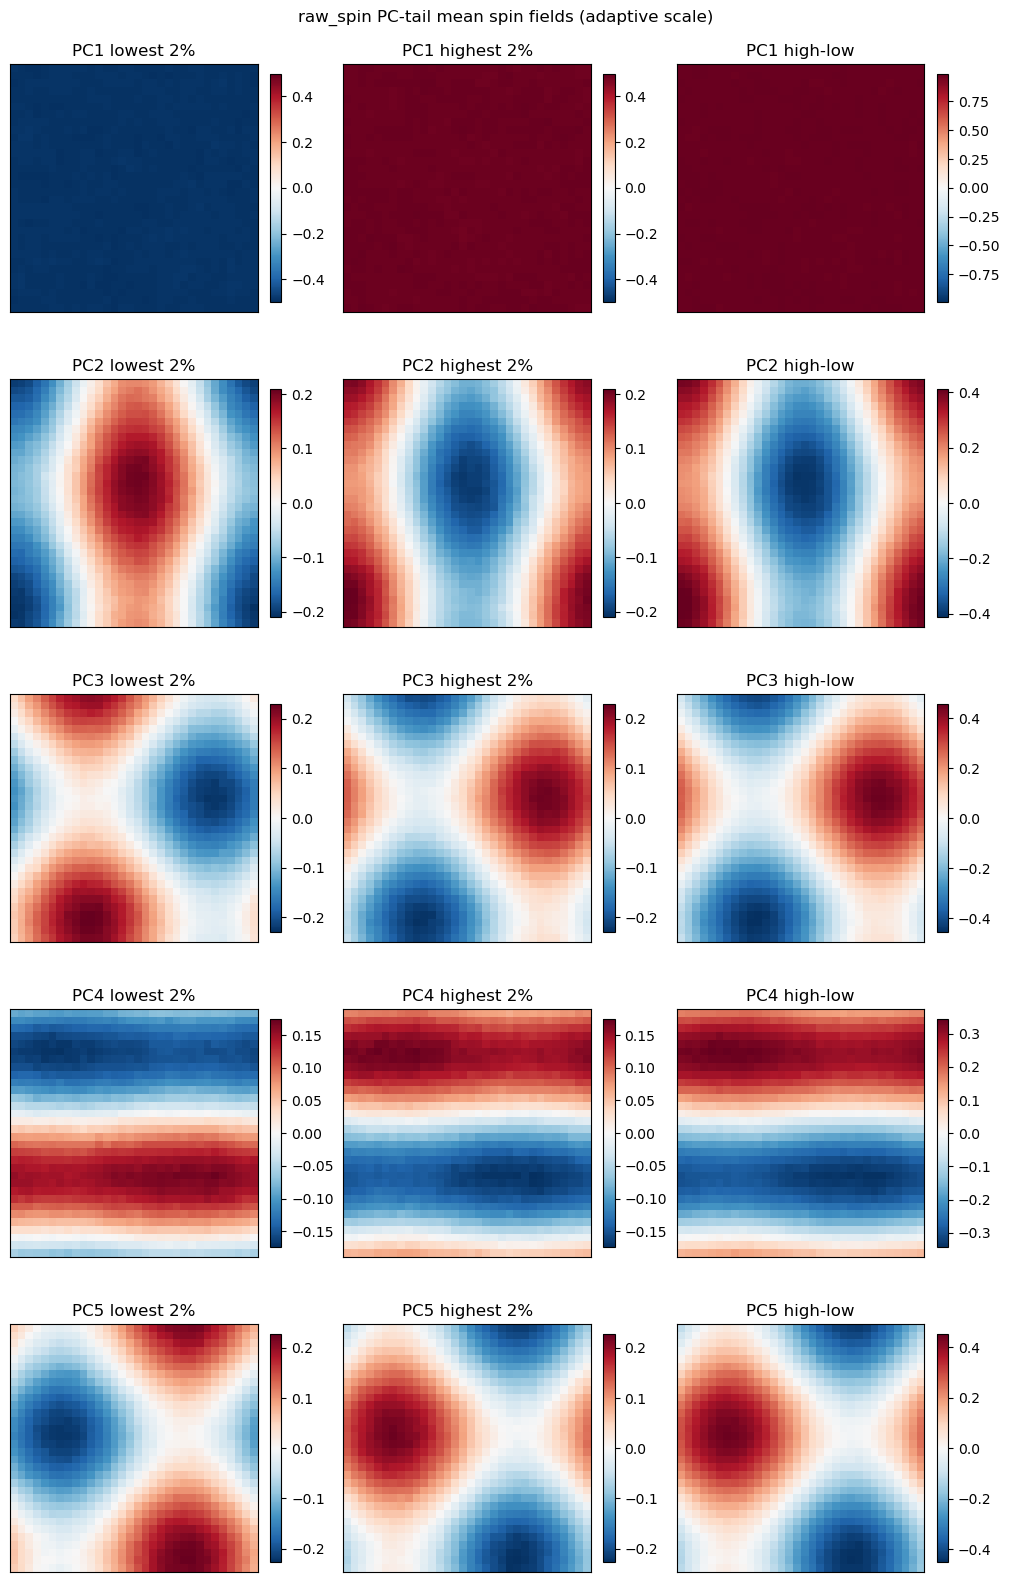

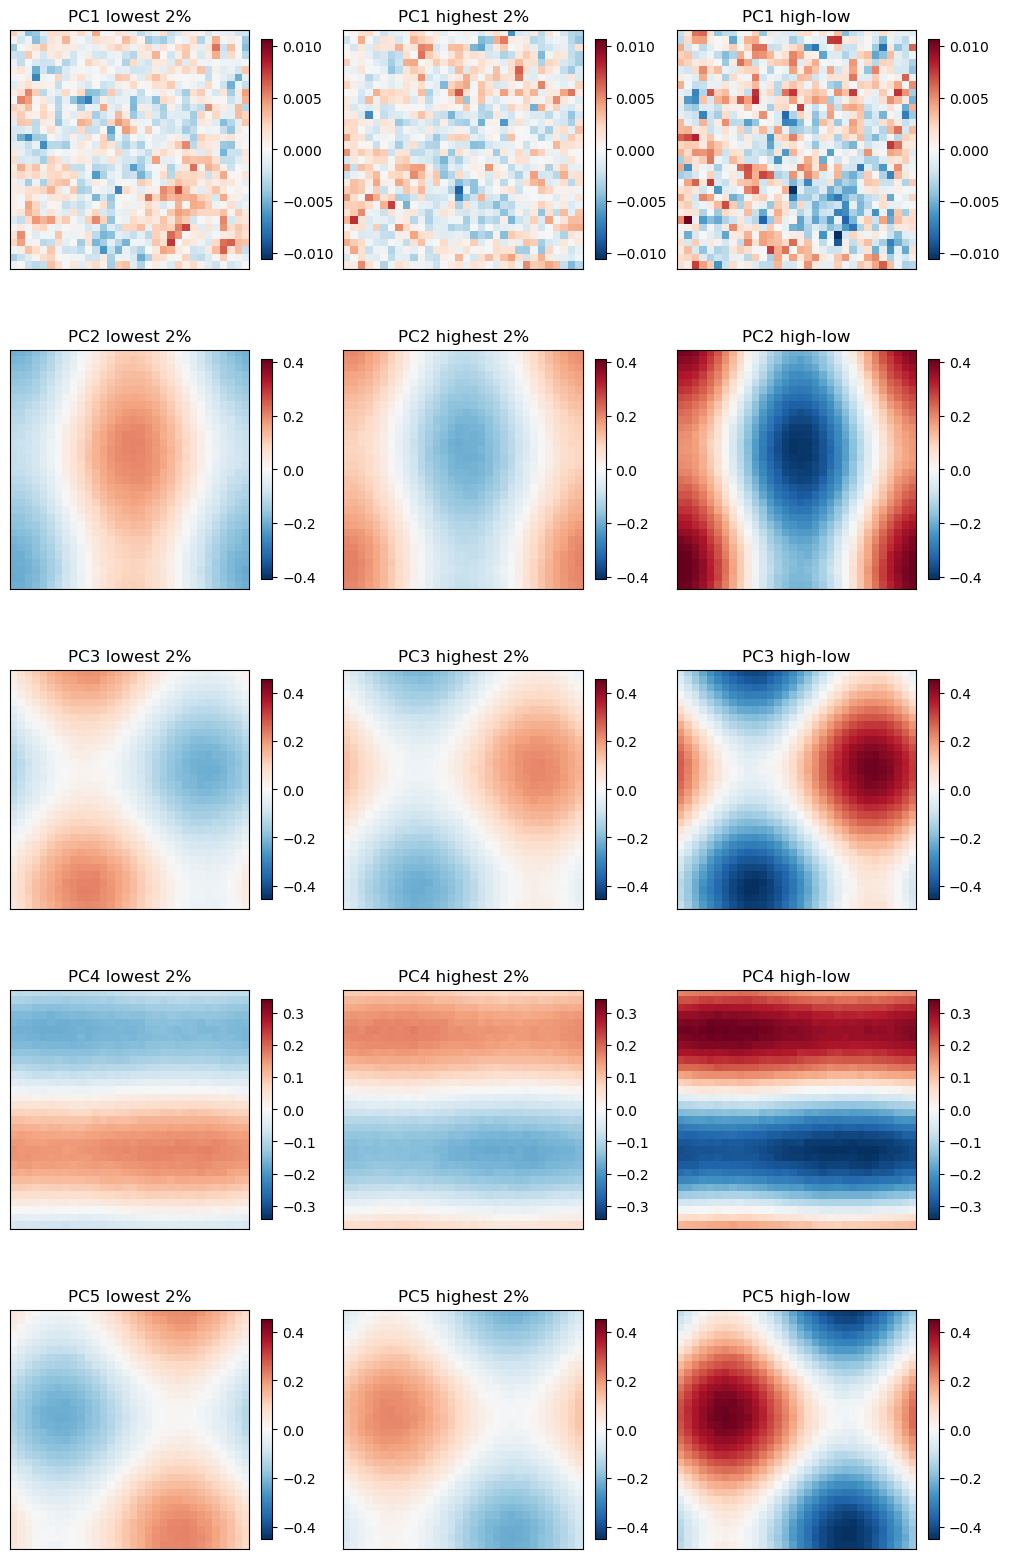

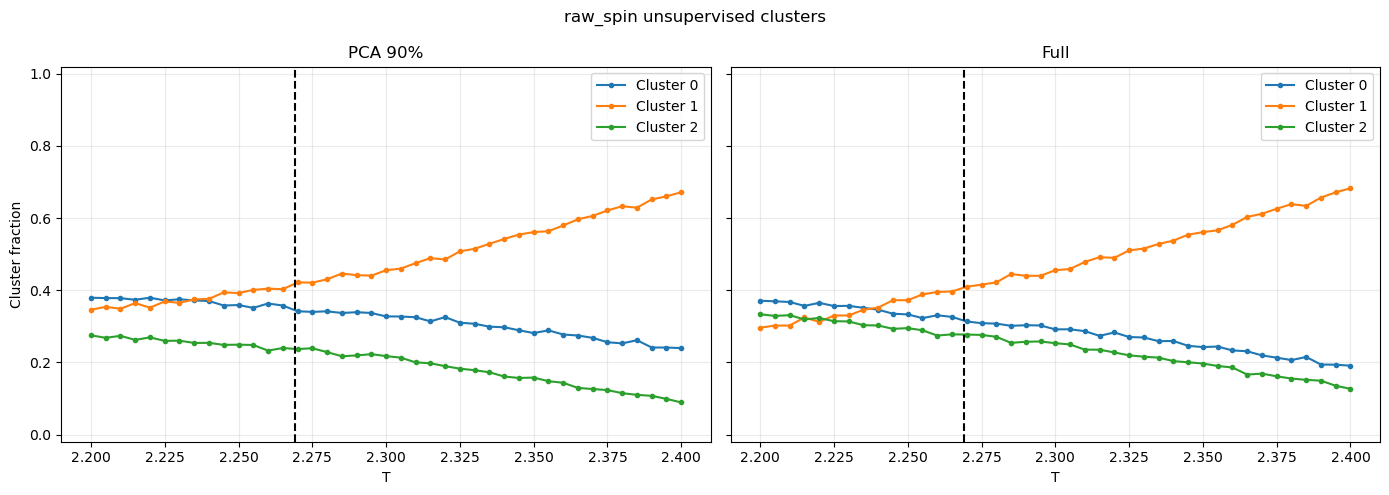

In [4]:
raw_features=mean_spins.reshape(-1,L*L)
raw_mean,raw_eigenvalues,raw_components=exact_pca(raw_features,"raw_spin_pca.npz",batch_size=2048)
raw_evr,raw_cumulative,raw_n90=variance_plot(raw_eigenvalues,"raw_spin")
raw_scores=score_memmap(raw_features,raw_mean,raw_components[:raw_n90],OUTPUT_ROOT/"raw_spin_pca90_scores.npy",batch_size=4096)
pc_visuals(raw_scores,"raw_spin")
raw_labels=cluster_analysis(raw_features,raw_scores,"raw_spin")
with open(OUTPUT_ROOT/"raw_spin_summary.json","w") as f: json.dump({"n_components_90":raw_n90,"variance_first5":raw_evr[:5].tolist()},f,indent=2)

## Direct comparison with frozen ResNet

In [5]:
with open(OUTPUT_ROOT/"resnet18_summary.json") as f: resnet_summary=json.load(f)
resnet_cluster=np.load(OUTPUT_ROOT/"resnet18_cluster_labels.npz")
raw_cluster=np.load(OUTPUT_ROOT/"raw_spin_cluster_labels.npz")
rng=np.random.default_rng(42); sample=rng.choice(len(raw_features),size=50000,replace=False)
comparison=pd.DataFrame([
    {"representation":"Frozen ResNet-18","PCs_for_90pct":resnet_summary["n_components_90"],"AMI_PCA90_vs_full":adjusted_mutual_info_score(resnet_cluster["pca90"],resnet_cluster["full"])},
    {"representation":"Raw spin field","PCs_for_90pct":raw_n90,"AMI_PCA90_vs_full":adjusted_mutual_info_score(raw_cluster["pca90"],raw_cluster["full"])},
])
cross_ami=adjusted_mutual_info_score(resnet_cluster["pca90"],raw_cluster["pca90"])
comparison["ResNet_raw_PCA90_AMI"]=cross_ami
comparison.to_csv(OUTPUT_ROOT/"resnet_vs_raw_pca_comparison.csv",index=False)
comparison

,representation,PCs_for_90pct,AMI_PCA90_vs_full,ResNet_raw_PCA90_AMI
0,Frozen ResNet-18,16,0.937148,0.280583
1,Raw spin field,579,0.768574,0.280583


In [6]:
rng = np.random.default_rng(42)
silhouette_indices = np.sort(rng.choice(len(raw_features), size=10_000, replace=False))
resnet_scores = np.load(OUTPUT_ROOT / "resnet18_pca90_scores.npy", mmap_mode="r")
resnet_silhouette = silhouette_score(
    np.asarray(resnet_scores[silhouette_indices]),
    resnet_cluster["pca90"][silhouette_indices],
)
raw_silhouette = silhouette_score(
    np.asarray(raw_scores[silhouette_indices]),
    raw_cluster["pca90"][silhouette_indices],
)

quality = pd.DataFrame([
    {"representation": "Frozen ResNet-18", "silhouette_PCA90": resnet_silhouette},
    {"representation": "Raw spin field", "silhouette_PCA90": raw_silhouette},
])
quality.to_csv(OUTPUT_ROOT / "resnet_vs_raw_pca_cluster_quality.csv", index=False)
quality

,representation,silhouette_PCA90
0,Frozen ResNet-18,0.326797
1,Raw spin field,0.128849


## Interpretation

The frozen ResNet representation is dramatically more compact: **16 PCs** retain 90% of its variance, whereas raw-spin PCA needs **579 PCs**. Its three-cluster separation is also substantially cleaner on the same 10,000-observation sample (silhouette **0.327** versus **0.129**), and reducing ResNet to its 90% PCA space preserves the full-embedding clusters well (AMI **0.937**, versus **0.769** for raw spins).

The two PCA clusterings agree only weakly (AMI **0.281**). ResNet produces a much sharper temperature-dependent transfer into a high-temperature cluster, while raw linear PCA remains dominated by the signed uniform magnetization direction and many nearly degenerate spatial fluctuation modes. Raw PC1 alone is essentially signed magnetization; its higher PCs have nearly zero tail-averaged total magnetization and describe spatial fluctuations.

This is evidence that pretrained ResNet provides a useful **nonlinear reorganization and compression** of phase-related morphology that ordinary linear PCA does not isolate compactly. It is not evidence that ResNet has discovered a new thermodynamic observable unavailable from the spins: all of its input information is contained in the raw configurations, and the current extrema/tail maps do not identify a new physical order parameter beyond magnetization and domain structure.